# QQQ / BOXX — six strategies, one backtest

Larry Connors' **RSI(2)** mean reversion, Antonacci's **GEM** dual momentum, a
**volatility-targeting overlay**, and **top-6 cross-sectional momentum on the
Nasdaq-100** — run over the same window, on the same data, with the same execution
assumptions, so the comparison is about the strategies and not about the plumbing.

| | What it is betting on | What it holds |
|---|---|---|
| **Connors RSI(2)** | short-term mean reversion inside an uptrend | QQQ in bursts of a few days, BOXX the rest of the time |
| **GEM** | 12-month momentum persists at the index level | whichever of QQQ / VEU is stronger, or BOXX if neither beats cash |
| **Vol targeting** | risk, not direction, is the forecastable thing | QQQ scaled so forecast vol ≈ 15%, remainder in BOXX |
| **Top-6 NDX momentum** | 12-month momentum persists at the *stock* level | the 6 strongest Nasdaq-100 names, held through a hysteresis band |
| **Top-6 + VIX breaker** | high implied vol predicts trouble worth sitting out | the same 6 names, switched entirely to cash when VIX crosses its trigger |

**Window:** 2025-01-20 (inauguration) to today.
**BOXX** — the Alpha Architect 1-3 Month Box ETF — is the cash leg throughout: a
box-spread structure that tracks short T-bill yields. Using it as the safe asset
(rather than a 0% cash line) is what makes the risk-adjusted numbers honest, since
a lot of what a defensive strategy earns in a 4–5% rate world is simply the cash rate.

**Execution model matches the intended live design:** decide near the close, fill in
the closing auction (MOC), one day of lag before the position earns anything. The
gap between the ~15:30 decision price and the 16:00 fill is carried as an explicit
`slippage_bps` assumption, reported separately from commission.

> ⚠️ **Two things will make these numbers look better than reality.** The Nasdaq-100
> universe is *today's* membership applied to all history — survivorship bias, and for
> a momentum strategy it is the worst kind. And a twenty-month sample is far too short
> to distinguish skill from luck. Section 12 spells both out. Read it before you act
> on anything here.

## 1. Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))     # so `qbs` imports when run from notebooks/
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qbs.config import (BookVolTargetParams, Config, GEMParams, MomentumParams,
                        RSI2Params, VixBreakerParams, VolTargetParams, STRATEGY_LABELS)
from qbs.data import load_prices, synthetic_prices
from qbs.engine import run_backtest, equity_frame
from qbs.metrics import summary_table, format_summary, trade_log, monthly_returns
from qbs.pipeline import run, build_signals, sweep_band, sweep_target_vol, sweep_vix
from qbs.universe import load_universe, load_pit_universe, membership_mask
from qbs import plotting as P

P.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
print("ready")

ready


## 2. Configuration

Everything tuneable is here. Change a number, re-run the notebook from this cell
down, and every chart and statistic below updates.

In [ ]:
cfg = Config()

cfg.backtest_start = "2022-01-20"     # inauguration day
cfg.backtest_end   = None             # None -> most recent close
cfg.download_start = "2020-06-01"     # earlier than the backtest: indicators need warm-up
cfg.cost_bps       = 1.0              # commission, bps per 100% of turnover per leg
cfg.slippage_bps   = 5.0              # 15:30 decision price vs 16:00 MOC fill
cfg.execution_lag  = 1                # signal at today's close -> position from tomorrow

cfg.rsi2 = RSI2Params(entry_threshold=5.0, exit_rsi=70.0,
                      trend_sma=200, exit_sma=5, max_hold_days=10)
cfg.gem  = GEMParams(lookback_months=12)
cfg.vol  = VolTargetParams(target_vol=0.15, halflife=20,
                           max_weight=1.0, rebalance_band=0.05)

cfg.momentum = MomentumParams(
    lookback_months=12,   # 12-1 momentum: rank on the return from 12 months ago
    skip_months=1,        #   to 1 month ago. The recent month is skipped because
                          #   short-horizon returns reverse rather than persist.
    n_hold=6,             # hold the 6 strongest
    exit_rank=10,         # hysteresis band: sell only once a name falls past rank 10
    rebalance="daily",    # evaluate every day, as the live design does
    weighting="equal",    # "equal" | "inv_vol"
    absolute_filter=True, # a name must also beat BOXX's own 12-1 return
)

cfg.vix = VixBreakerParams(
    exit_level=18.0,      # VIX close above this -> sell everything to cash
    entry_level=17.0,     # VIX below this -> resume the momentum book
    park_after_days=3,    # still elevated after 3 days -> move the cash into BOXX
    min_cash_days=2,      # minimum dwell in cash, even if VIX recovers at once
)

# Book-level vol targeting: scales the WHOLE momentum book by its own
# realised vol. This is the drawdown control that works on the 2026-style
# episodes, where the book blew up while VIX stayed below its median.
cfg.book_vol = BookVolTargetParams(
    target_vol=0.25,      # 0.15 conservative · 0.25 default · 0.40 barely a brake
    halflife=20,          # EWMA halflife for the book's own vol
    max_weight=1.0,       # 1.0 = de-risk only, never lever the book up
    rebalance_band=0.05,  # no-trade band on the scalar
)

pd.Series(
    {"start": cfg.backtest_start, "commission (bps)": cfg.cost_bps,
     "slippage (bps)": cfg.slippage_bps,
     "RSI entry": cfg.rsi2.entry_threshold, "trend filter": f"SMA{cfg.rsi2.trend_sma}",
     "GEM lookback": f"{cfg.gem.lookback_months}m", "vol target": f"{cfg.vol.target_vol:.0%}",
     "momentum": f"top {cfg.momentum.n_hold}, exit past rank {cfg.momentum.exit_rank}",
     "band width": cfg.momentum.exit_rank - cfg.momentum.n_hold,
     "VIX trigger": f"out above {cfg.vix.exit_level:g}, in below {cfg.vix.entry_level:g}",
     "book vol target": f"{cfg.book_vol.target_vol:.0%}"},
    name="setting").to_frame()

,setting
start,2022-01-20
commission (bps),1.0
slippage (bps),5.0
RSI entry,5.0
trend filter,SMA200
GEM lookback,12m
vol target,15%
momentum,"top 6, exit past rank 10"
band width,4
VIX trigger,"out above 17, in below 17"


## 3. Data

Two downloads: the three core ETFs (QQQ / VEU / BOXX), and the ~100 Nasdaq-100
constituents used for momentum ranking. Both cache to `../data/`, so the first run is
slow and every run after it is instant.

`FETCH_UNIVERSE = True` scrapes the current Nasdaq-100 membership list; if that fails
it falls back to a hardcoded list in `qbs/universe.py`. **Either way you are ranking
against today's membership** — see the survivorship-bias note in section 12 and the
point-in-time hook in `qbs/universe.py` if you want to fix it properly.

`USE_SYNTHETIC = True` swaps in a generated market (including a fake 100-name universe
with a real momentum effect built in) so the whole notebook runs with no network —
useful for checking the plumbing, useless for drawing conclusions.

In [3]:
USE_SYNTHETIC  = False    # True -> generated prices, no network, results are meaningless
REFRESH        = False    # True -> re-download even if the cache has the data
FETCH_UNIVERSE = True     # True -> scrape current NDX membership; False -> hardcoded list

try:
    lab = run(cfg, offline=False, refresh=REFRESH, use_synthetic=USE_SYNTHETIC,
              with_momentum=True, fetch_universe=FETCH_UNIVERSE)
    source = "synthetic" if USE_SYNTHETIC else "yfinance"
except Exception as exc:
    print(f"Live download failed ({type(exc).__name__}: {exc})")
    print("Falling back to synthetic prices so the notebook still runs end to end.")
    lab = run(cfg, use_synthetic=True)
    source = "synthetic (fallback)"

px = lab.prices
print(f"source: {source}")
print(f"core:     {len(px)} rows, {px.index.min():%Y-%m-%d} to {px.index.max():%Y-%m-%d}")
if lab.universe is not None:
    print(f"universe: {lab.universe.shape[1]} tickers, {len(lab.universe)} rows")
px.tail()

[universe] live fetch failed (HTTP Error 403: Forbidden); using NDX_FALLBACK (as of 2026-09) -- results carry survivorship bias.
[universe] using NDX_FALLBACK (as of 2026-09). This is today's membership applied to all history: survivorship bias. See qbs/universe.py for how to supply point-in-time membership.
[universe] cache hit: 99/99 tickers, 2020-06-01 to 2026-09-08
source: yfinance
core:     926 rows, 2022-12-28 to 2026-09-08
universe: 99 tickers, 1576 rows


,QQQ,VEU,BOXX
Date,,,
2026-09-01,707.640015,84.650002,118.110001
2026-09-02,709.239990,85.129997,118.059998
2026-09-03,717.669983,85.949997,118.080002
2026-09-04,718.960022,86.410004,118.129997
2026-09-08,718.359985,86.059998,118.129997


In [4]:
# Sanity checks before trusting anything downstream.
checks = pd.DataFrame({
    "first": px.apply(lambda s: s.first_valid_index()),
    "last": px.apply(lambda s: s.last_valid_index()),
    "missing": px.isna().sum(),
    "min": px.min().round(2),
    "max": px.max().round(2),
    "worst 1d": px.pct_change().min().map(lambda v: f"{v:.2%}"),
    "best 1d": px.pct_change().max().map(lambda v: f"{v:.2%}"),
})
print("BOXX annualised drift over the sample: "
      f"{(px['BOXX'].iloc[-1] / px['BOXX'].iloc[0]) ** (252 / len(px)) - 1:.2%}"
      "   <- should look like a T-bill yield, not an equity return")
checks

BOXX annualised drift over the sample: 4.71%   <- should look like a T-bill yield, not an equity return


,first,last,missing,min,max,worst 1d,best 1d
QQQ,2022-12-28,2026-09-08,0,254.89,745.34,-6.21%,12.00%
VEU,2022-12-28,2026-09-08,0,44.95,86.41,-6.12%,7.20%
BOXX,2022-12-28,2026-09-08,0,99.76,118.13,-0.12%,0.14%


## 4. Run the backtests

`run()` already did this, but here it is explicitly: each strategy produces target
weights *decided at each close*, and the engine applies the one-day execution lag,
the transaction costs and the window trim identically for all of them.

In [5]:
lab.summary_pretty

,Total return,CAGR,Ann. vol,Sharpe (vs BOXX),Sortino,Max drawdown,Calmar,Best day,Worst day,Hit rate,Avg risk exposure,Days in risk,Ann. turnover,Cost drag (ann.),of which slippage
Connors RSI(2),28.5%,7.1%,5.5%,0.44,0.68,-5.9%,1.19,3.4%,-2.8%,73.1%,5.6%,5.6%,18.8x,1.1%,0.9%
GEM dual momentum,82.9%,17.9%,16.7%,0.79,1.14,-22.3%,0.80,7.2%,-6.1%,41.5%,72.6%,72.6%,4.1x,0.2%,0.2%
Vol-targeted QQQ,97.7%,20.4%,14.9%,1.01,1.44,-15.9%,1.28,5.7%,-4.3%,57.7%,77.9%,97.7%,3.6x,0.2%,0.2%
Buy & hold QQQ,181.7%,32.6%,20.2%,1.27,1.90,-22.8%,1.43,12.0%,-6.2%,56.8%,99.9%,99.9%,0.3x,0.0%,0.0%
Buy & hold BOXX,18.3%,4.7%,0.4%,-0.04,-0.52,-0.1%,40.46,0.1%,-0.1%,75.6%,0.0%,0.0%,0.3x,0.0%,0.0%
Top-6 NDX momentum,458.1%,59.7%,39.7%,1.26,1.92,-34.8%,1.71,14.6%,-10.2%,60.4%,71.9%,71.9%,4.1x,0.2%,0.2%
Top-6 + VIX breaker,49.9%,11.6%,25.6%,0.38,0.54,-32.9%,0.35,10.0%,-9.4%,53.7%,38.4%,38.4%,34.7x,2.1%,1.7%


In [6]:
# Same table, raw numbers, if you want to sort or chart it.
lab.summary.round(4)

,Total return,CAGR,Ann. vol,Sharpe (vs BOXX),Sortino,Max drawdown,Calmar,Best day,Worst day,Hit rate,Avg risk exposure,Days in risk,Ann. turnover,Cost drag (ann.),of which slippage
Connors RSI(2),0.2852,0.0707,0.0546,0.4355,0.6759,-0.0592,1.1941,0.0338,-0.0278,0.7311,0.0562,0.0562,18.7775,0.0113,0.0094
GEM dual momentum,0.8289,0.1786,0.1666,0.7935,1.1372,-0.2233,0.7995,0.0720,-0.0612,0.4147,0.7257,0.7257,4.0821,0.0024,0.0020
Vol-targeted QQQ,0.9769,0.2038,0.1489,1.0113,1.4391,-0.1594,1.2784,0.0571,-0.0433,0.5767,0.7788,0.9773,3.6486,0.0022,0.0018
Buy & hold QQQ,1.8166,0.3255,0.2017,1.2704,1.8992,-0.2277,1.4297,0.1200,-0.0621,0.5680,0.9989,0.9989,0.2721,0.0002,0.0001
Buy & hold BOXX,0.1834,0.0469,0.0037,-0.0442,-0.5217,-0.0012,40.4600,0.0014,-0.0012,0.7559,0.0000,0.0000,0.2721,0.0002,0.0001
Top-6 NDX momentum,4.5811,0.5967,0.3967,1.2623,1.9153,-0.3483,1.7128,0.1463,-0.1018,0.6037,0.7192,0.7192,4.0821,0.0024,0.0020
Top-6 + VIX breaker,0.4991,0.1165,0.2563,0.3787,0.5445,-0.3294,0.3536,0.0999,-0.0940,0.5367,0.3844,0.3844,34.6523,0.0208,0.0173


## 5. Equity curves and drawdowns

Growth of $1 from the first day of the window. Both benchmarks are drawn in grey and
dashed so a strategy line never has to compete with them for attention.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


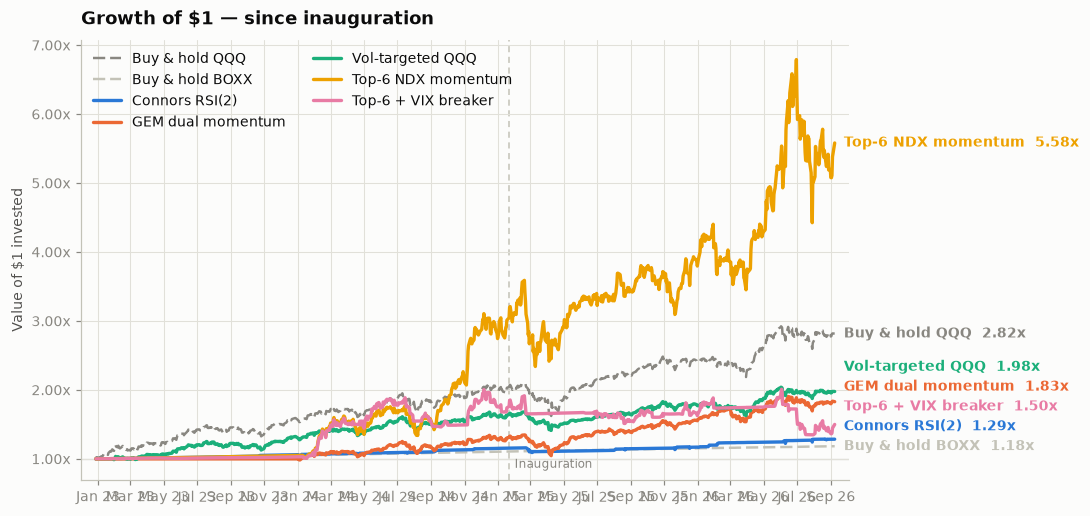

In [7]:
P.plot_equity_curves(lab.results, title="Growth of $1 — since inauguration")
plt.show()

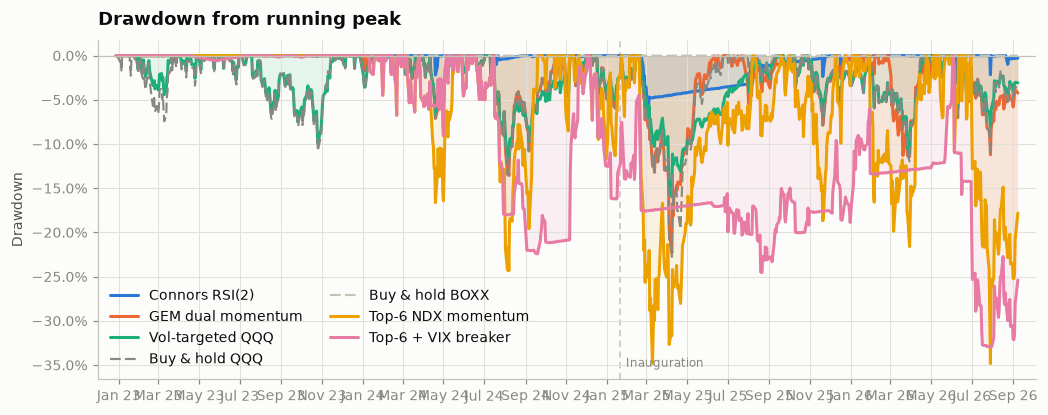

In [8]:
P.plot_drawdowns(lab.results)
plt.show()

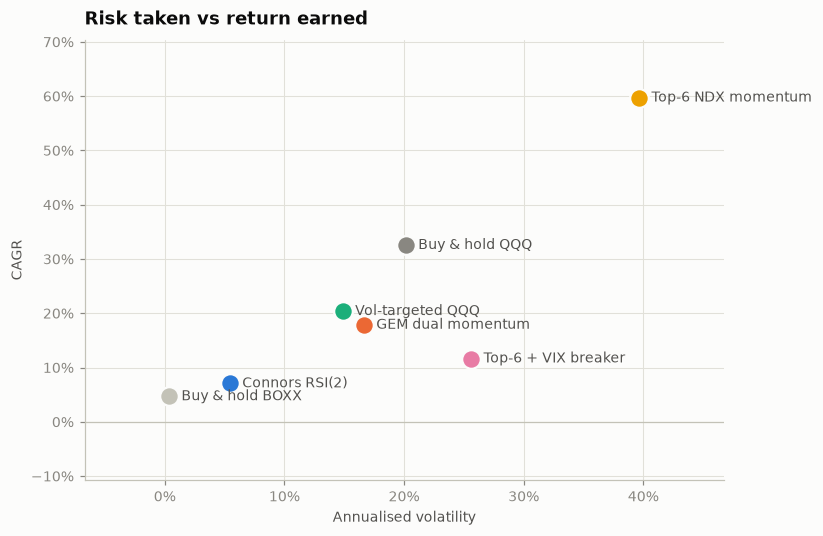

In [9]:
P.plot_return_scatter(lab.results, rf=lab.rf)
plt.show()

## 6. Where the signals actually fired

This is the part the summary table cannot show you: *when* each strategy decided to
be in or out, and what it was looking at when it decided.

### 6a. Connors RSI(2)

Top panel: QQQ with the SMA(200) trend filter and the SMA(5) exit line. Grey bands are
the stretches where price sits below SMA(200) and **no new long may be opened** — the
single rule that separates buying a pullback from catching a falling knife.
Bottom panel: RSI(2) itself, with the buy and sell thresholds.

findfont: Failed to find font weight 600, now using 700.


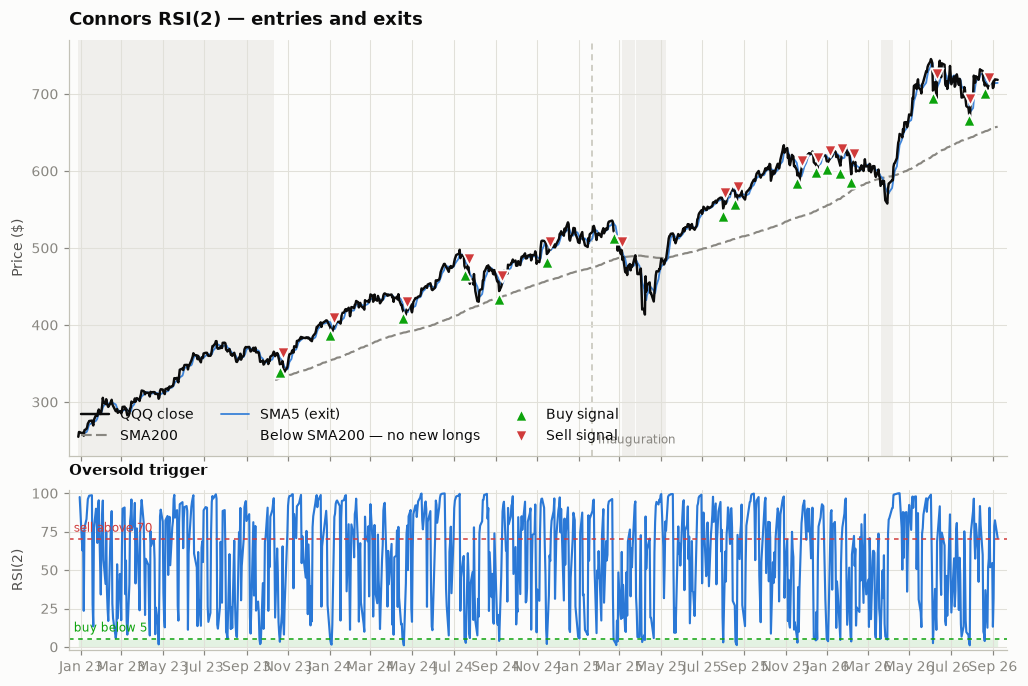

In [10]:
fig = P.plot_rsi2_signals(lab.signals["rsi2"], lab.results["rsi2"].start, lab.results["rsi2"].end)
plt.show()

In [11]:
tl = trade_log(lab.results["rsi2"])
if tl.empty:
    print("No completed round trips in this window — RSI(2) < 5 above the 200-day is a rare event.")
else:
    print(f"{len(tl)} round trips | win rate {(tl['ret'] > 0).mean():.0%} | "
          f"avg {tl['ret'].mean():+.2%} | median hold {tl['days'].median():.0f} trading days")
    display(tl.assign(ret=tl["ret"].map(lambda v: f"{v:+.2%}")))

17 round trips | win rate 88% | avg +0.80% | median hold 3 trading days


,entry,exit,asset,entry_px,exit_px,ret,days,exit_reason
0,2023-10-20,2023-10-24,QQQ,349.019165,353.477844,+1.28%,2,close > SMA(5)
1,2024-01-02,2024-01-08,QQQ,397.254120,399.582916,+0.59%,4,close > SMA(5)
2,2024-04-18,2024-04-23,QQQ,418.350708,419.990845,+0.39%,3,close > SMA(5)
3,2024-07-18,2024-07-23,QQQ,474.513611,475.631866,+0.24%,3,close > SMA(5)
4,2024-09-06,2024-09-10,QQQ,444.033264,453.899811,+2.22%,2,close > SMA(5)
5,2024-11-15,2024-11-20,QQQ,492.106934,498.647583,+1.33%,3,close > SMA(5)
6,2025-02-21,2025-03-05,QQQ,522.192322,498.300262,-4.58%,8,close > SMA(5)
7,2025-08-01,2025-08-04,QQQ,551.225220,561.396118,+1.85%,1,close > SMA(5)
8,2025-08-19,2025-08-22,QQQ,566.551392,569.228455,+0.47%,3,close > SMA(5)
9,2025-11-18,2025-11-24,QQQ,594.139771,602.957581,+1.48%,4,close > SMA(5)


### 6b. GEM

Top panel: the three sleeves rebased to 1.0, with the background shaded by **what GEM
was actually holding**. Bottom panel: the 12-month trailing return of each sleeve,
sampled at each month end — the numbers the monthly decision is made from. GEM holds
equity only when the stronger equity sleeve is above the BOXX line.

findfont: Failed to find font weight 600, now using 700.


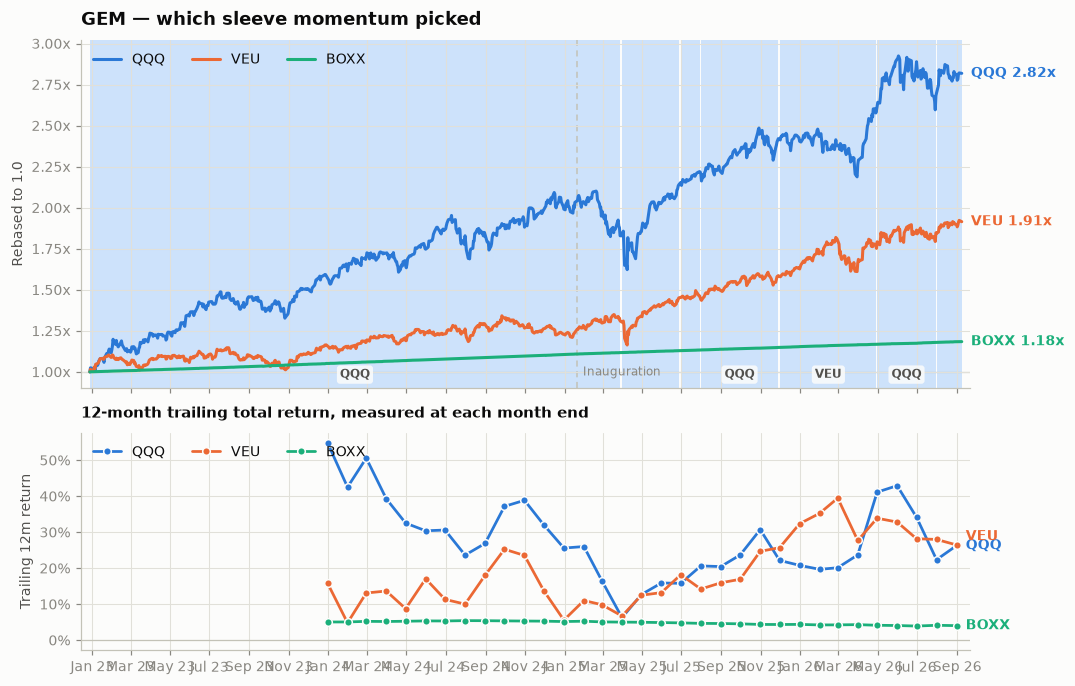

In [12]:
fig = P.plot_gem_signals(lab.prices, lab.signals["gem"],
                         lab.results["gem"].start, lab.results["gem"].end)
plt.show()

In [13]:
d = lab.signals["gem"].diagnostics
d = d[(d.index >= lab.results["gem"].start) & (d.index <= lab.results["gem"].end)]
view = d.copy()
for c in [c for c in view.columns if c.startswith("mom_")]:
    view[c] = view[c].map(lambda v: f"{v:+.1%}")
view.index = view.index.strftime("%Y-%m")
print("Month-end decisions (the 'pick' column is held for the following month):")
view

Month-end decisions (the 'pick' column is held for the following month):


,leader,pick,mom_QQQ,mom_VEU,mom_BOXX
date,,,,,
2023-12,QQQ,QQQ,+54.9%,+15.8%,+5.0%
2024-01,QQQ,QQQ,+42.5%,+4.8%,+5.0%
2024-02,QQQ,QQQ,+50.6%,+13.1%,+5.2%
2024-03,QQQ,QQQ,+39.3%,+13.6%,+5.2%
2024-04,QQQ,QQQ,+32.5%,+8.7%,+5.2%
2024-05,QQQ,QQQ,+30.4%,+17.0%,+5.3%
2024-06,QQQ,QQQ,+30.6%,+11.3%,+5.3%
2024-07,QQQ,QQQ,+23.6%,+10.0%,+5.4%
2024-08,QQQ,QQQ,+26.9%,+18.0%,+5.4%


### 6c. Vol targeting

Three stacked panels, one x-axis. Price with every exposure change marked; the EWMA
volatility forecast against the 15% target; and the weight actually held.

The dashed grey line in the bottom panel is the *unbanded* target — what a naive
implementation would trade to every single day. The solid line is what the no-trade
band actually holds. The gap between them is turnover you don't pay for.

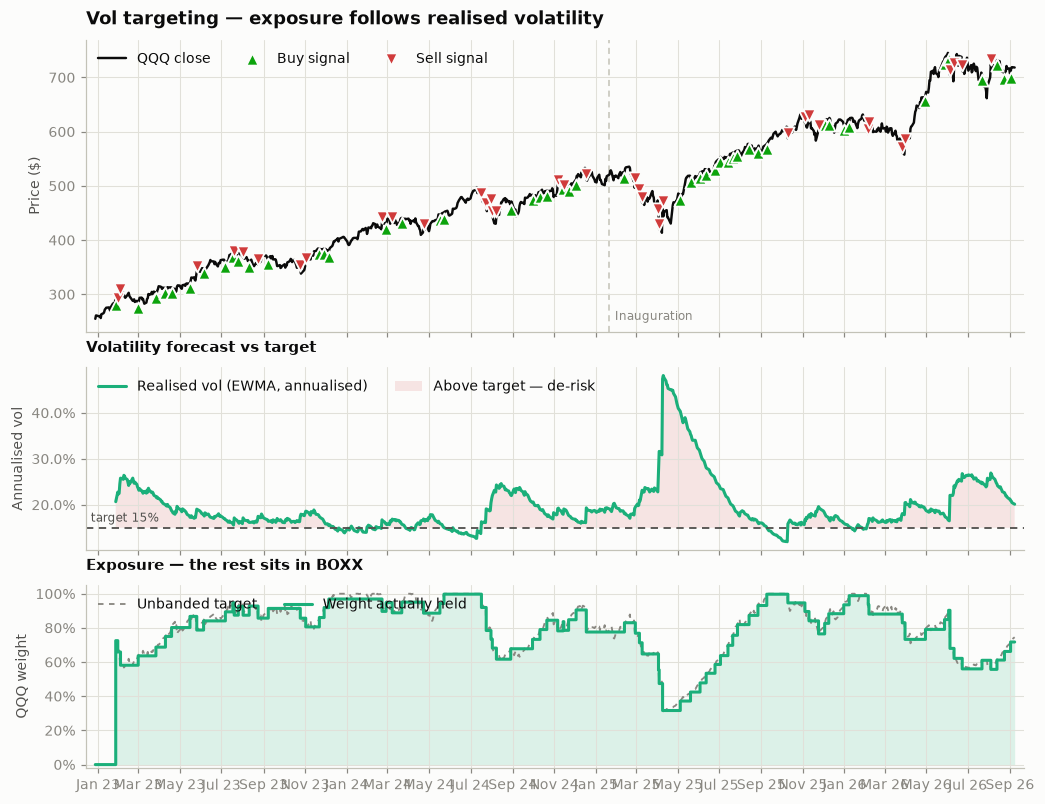

In [14]:
fig = P.plot_voltarget_signals(lab.signals["voltarget"], cfg.vol.target_vol,
                               lab.results["voltarget"].start, lab.results["voltarget"].end)
plt.show()

In [15]:
vt = lab.signals["voltarget"].diagnostics.loc[lab.results["voltarget"].start:]
realised = lab.results["voltarget"].returns.std() * np.sqrt(252)
print(f"Target vol                  {cfg.vol.target_vol:.1%}")
print(f"Vol the strategy delivered  {realised:.1%}")
print(f"QQQ's own vol               {lab.results['bh_qqq'].returns.std() * np.sqrt(252):.1%}")
print(f"Average QQQ weight          {vt['risk_weight'].mean():.0%}"
      f"  (min {vt['risk_weight'].min():.0%}, max {vt['risk_weight'].max():.0%})")
print(f"Days the weight moved       {(vt['risk_weight'].diff().abs() > 1e-9).sum()} of {len(vt)}")

Target vol                  15.0%
Vol the strategy delivered  14.9%
QQQ's own vol               20.2%
Average QQQ weight          78%  (min 0%, max 100%)
Days the weight moved       87 of 926


### 6d. Top-6 Nasdaq-100 momentum

The chart below is the one worth studying. Each row is a stock; each bar is a stretch
where it was held. A strategy that works looks like a handful of long bars — winners
held for months. A strategy that is mostly paying spread looks like confetti.

The hysteresis band is what separates those two pictures. Without it, a name that
slips from rank 6 to rank 7 is sold and often bought back days later.

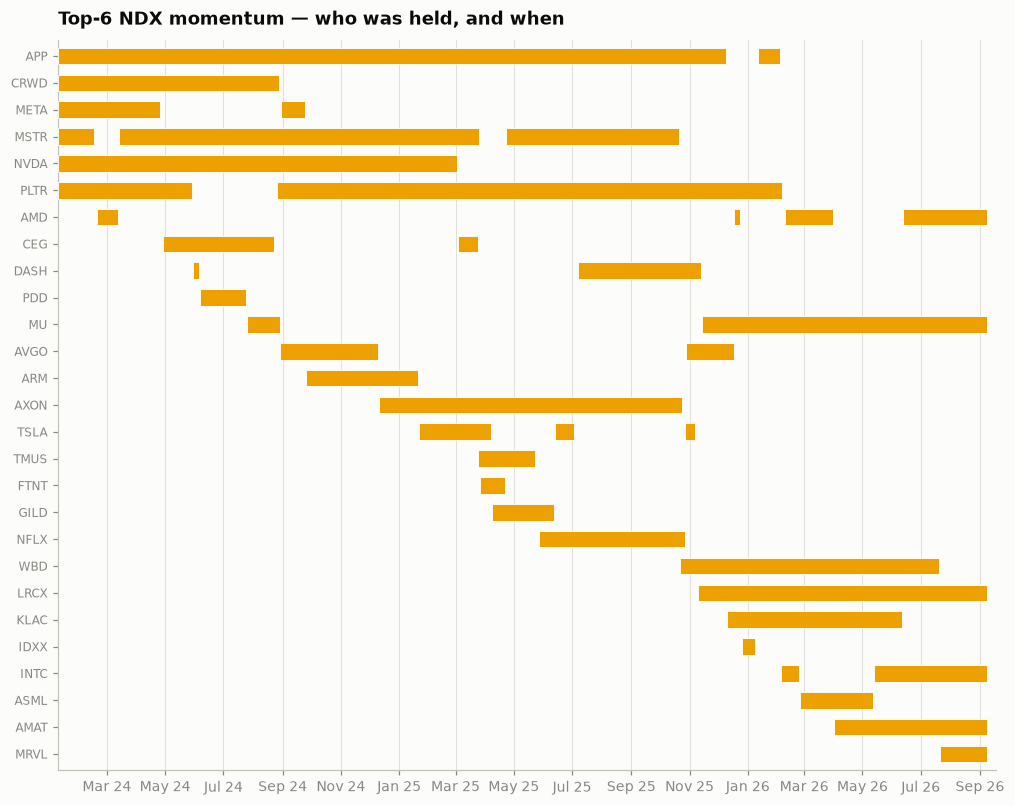

In [16]:
fig = P.plot_momentum_holdings(lab.signals["momentum"],
                               lab.results["momentum"].start,
                               lab.results["momentum"].end)
plt.show()

In [17]:
m = lab.signals["momentum"]
ev = m.events[(m.events["date"] >= lab.results["momentum"].start) &
              (m.events["date"] <= lab.results["momentum"].end)]
log = {d: v for d, v in (m.holdings_log or {}).items()
       if lab.results["momentum"].start <= d <= lab.results["momentum"].end}

from collections import Counter
tenure = Counter()
for d, names in log.items():
    tenure.update(names)

print(f"Distinct names touched : {len(tenure)}")
print(f"Buys / sells           : {(ev['action'] == 'buy').sum()} / {(ev['action'] == 'sell').sum()}")
print(f"Median holding length  : {np.median(list(tenure.values())):.0f} trading days")
print(f"Days with an empty slot: {(pd.Series({d: len(v) for d, v in log.items()}) < cfg.momentum.n_hold).mean():.1%}")
print("\nLongest-held names:")
pd.Series(dict(tenure.most_common(12)), name="trading days held").to_frame()

Distinct names touched : 27
Buys / sells           : 42 / 36
Median holding length  : 107 trading days
Days with an empty slot: 28.0%

Longest-held names:


,trading days held
APP,498
PLTR,461
MSTR,412
NVDA,286
MU,228
AXON,218
LRCX,207
WBD,185
CRWD,160
KLAC,126


In [18]:
# Most recent decisions — what the live system would be holding right now.
last = max(log)
print(f"Holdings as of {last:%Y-%m-%d}: {', '.join(log[last])}\n")
print("Last 12 signal events:")
ev.tail(12).assign(price=ev.tail(12)["price"].round(2)).to_string(index=False)

Holdings as of 2026-09-08: LRCX, MU, AMAT, INTC, AMD, MRVL

Last 12 signal events:


'      date action asset   price                   reason\n2026-02-09   sell  PLTR  142.91             rank 12 > 10\n2026-02-09    buy   AMD  216.00  rank 5, 12-1 mom +85.8%\n2026-02-25   sell  INTC   46.88             rank 11 > 10\n2026-02-25    buy  ASML 1521.22  rank 6, 12-1 mom +93.5%\n2026-04-01   sell   AMD  210.21             rank 11 > 10\n2026-04-01    buy  AMAT  352.98 rank 4, 12-1 mom +144.3%\n2026-05-13   sell  ASML 1579.54             rank 11 > 10\n2026-05-13    buy  INTC  120.29 rank 4, 12-1 mom +187.7%\n2026-06-12   sell  KLAC  254.25             rank 11 > 10\n2026-06-12    buy   AMD  511.57 rank 3, 12-1 mom +267.8%\n2026-07-21   sell   WBD   25.83             rank 11 > 10\n2026-07-21    buy  MRVL  207.96 rank 3, 12-1 mom +316.8%'

### 6e. The VIX circuit breaker

The switch is binary, not proportional: above the trigger the entire book goes to
cash; below the re-entry level it goes back on. Three panels, one x-axis — the
decision input, the decision, and what the decision cost.

The two thresholds form a hysteresis band on volatility, the same device as the
momentum rank band. A single threshold would round-trip the whole portfolio every
time VIX oscillated across it.

**The number to check first is "invested X% of the window" in the middle panel.** VIX
has a long-run median near 17–18. A trigger set at 17 therefore sits in the middle of
the distribution, and the strategy spends roughly half its life switched off — which
is a different strategy, not a protected one.

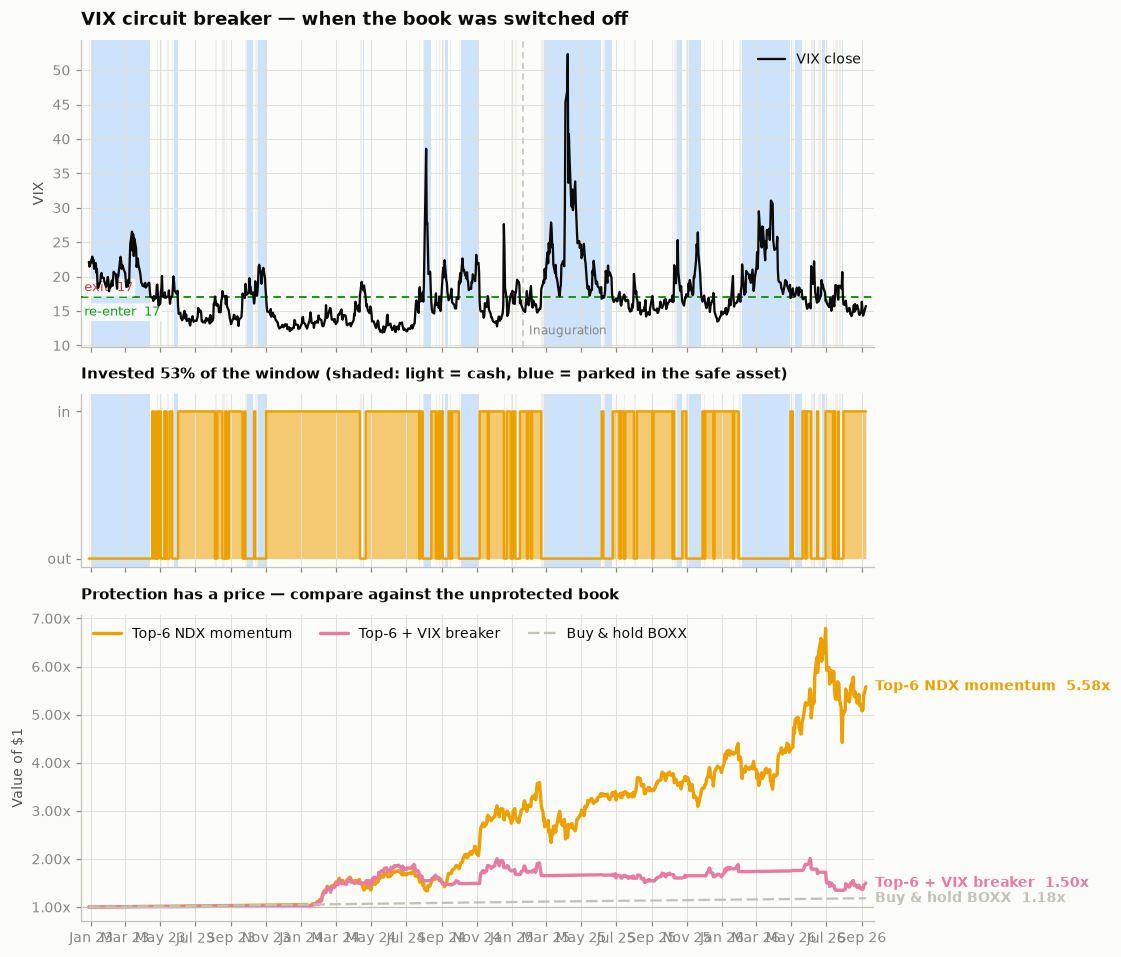

In [19]:
if "momentum_vix" in lab.signals:
    r = lab.results["momentum_vix"]
    fig = P.plot_vix_regimes(lab.signals["momentum_vix"], lab.results, r.start, r.end)
    plt.show()
else:
    print("No VIX data loaded — the circuit-breaker strategy was skipped.")

In [20]:
if "momentum_vix" in lab.signals:
    r  = lab.results["momentum_vix"]
    d  = lab.signals["momentum_vix"].diagnostics.loc[r.start:r.end]
    ev = lab.signals["momentum_vix"].events
    v  = lab.vix.loc[r.start:r.end]

    print(f"VIX over the window   median {v.median():.1f}   "
          f"p25 {v.quantile(.25):.1f}   p75 {v.quantile(.75):.1f}   max {v.max():.1f}")
    for t in (cfg.vix.entry_level, cfg.vix.exit_level, 20, 25, 30):
        print(f"  days above {t:g}: {(v > t).mean():.0%}")
    print()
    print(d["regime"].value_counts(normalize=True).mul(100).round(1).to_string())
    print(f"\ntrips to cash {int((ev['action']=='sell').sum())}   "
          f"parked {int((ev['action']=='park').sum())}   "
          f"re-entries {int((ev['action']=='buy').sum())}")

    a = lab.summary.loc[STRATEGY_LABELS["momentum"]]
    b = lab.summary.loc[STRATEGY_LABELS["momentum_vix"]]
    print(f"\n{'':22}{'unprotected':>13}{'with breaker':>15}")
    for k in ("CAGR", "Ann. vol", "Max drawdown", "Ann. turnover"):
        f = "{:.1%}" if k != "Ann. turnover" else "{:.1f}x"
        print(f"{k:22}{f.format(a[k]):>13}{f.format(b[k]):>15}")

VIX over the window   median 16.6   p25 14.7   p75 19.1   max 52.3
  days above 17: 45%
  days above 17: 45%
  days above 20: 18%
  days above 25: 4%
  days above 30: 2%

regime
INVESTED    52.7
PARKED      34.1
CASH        13.2

trips to cash 47   parked 19   re-entries 47

                        unprotected   with breaker
CAGR                          59.7%          11.6%
Ann. vol                      39.7%          25.6%
Max drawdown                 -34.8%         -32.9%
Ann. turnover                  4.1x          34.7x


### 6f. Book vol targeting — the drawdown control that actually works

The VIX breaker above fails for a specific, diagnosable reason, and it is worth
understanding before reaching for the fix.

The Top-6 book has **two different kinds of drawdown**:

| Episode | Book drawdown | VIX at the time | QQQ over the same days |
|---|---|---|---|
| 2025 market selloff | −31% | 28–45 — **visible** | −22.8% |
| 2026 concentration blow-up | −30% | **16–20** — invisible | −8.8% |

On 2026-07-28 the book lost **−7.7%** on a day QQQ lost 1.0%. On 2026-01-30, −7.8%
against QQQ's −1.2%. VIX sat *below its own median* through the worst of it. No
threshold on an index signal can catch that, because the index was not what went
wrong — six correlated semiconductors were.

The book itself, however, runs at roughly **49% annualised vol with a beta near 1.7**
to QQQ. Most of the drawdown is leverage, not stock selection. So target the
volatility of *the thing you actually hold*:

$$\text{scalar} = \frac{\text{target vol}}{\text{book's own realised vol}}, \quad \text{clipped to } [0, 1]$$

Every name is scaled by that one number, so relative position sizes never change —
this decides *how much* of the strategy you hold, never *which* names. The freed
weight parks in BOXX.

The third panel below is the whole argument: the book's own risk against VIX, on a
shared x-axis. Where the top line climbs and the bottom one doesn't, an index signal
is blind and this one is not.

In [ ]:
# ── The dial. Change this and re-run the cell. ──────────────────────────────
TARGET_VOL = cfg.book_vol.target_vol   # 0.25 default · 0.15 conservative · 0.40 barely any brake

from qbs.strategies import book_vol_target
from qbs.config import BookVolTargetParams
from qbs.engine import run_backtest

_p   = BookVolTargetParams(**{**cfg.book_vol.__dict__, "target_vol": TARGET_VOL})
_sig = book_vol_target(lab.signals["momentum"], lab.combined, _p, lag=cfg.execution_lag)
_res = run_backtest(lab.combined, _sig, start=cfg.backtest_start, end=cfg.backtest_end,
                    lag=cfg.execution_lag, cost_bps=cfg.cost_bps,
                    slippage_bps=cfg.slippage_bps)

fig = P.plot_book_voltarget(_sig, TARGET_VOL, _res.start, _res.end, vix=lab.vix)
plt.show()

In [ ]:
# Side by side with the unscaled book and with QQQ.
from qbs.metrics import summarise

_rows = {
    f"Top-6 vol-targeted {TARGET_VOL:.0%}": summarise(_res, rf=lab.rf),
    "Top-6 unscaled":                       summarise(lab.results["momentum"], rf=lab.rf),
    "Top-6 + VIX breaker":                  summarise(lab.results["momentum_vix"], rf=lab.rf),
    "Buy & hold QQQ":                       summarise(lab.results["bh_qqq"], rf=lab.rf),
}
_cols = ["CAGR", "Ann. vol", "Sharpe (vs BOXX)", "Max drawdown", "Calmar",
         "Ann. turnover", "Avg risk exposure"]
display(pd.DataFrame(_rows).T[_cols].style.format({
    "CAGR": "{:.1%}", "Ann. vol": "{:.1%}", "Sharpe (vs BOXX)": "{:.2f}",
    "Max drawdown": "{:.1%}", "Calmar": "{:.2f}", "Ann. turnover": "{:.1f}x",
    "Avg risk exposure": "{:.0%}"}))

In [ ]:
# The claim that motivates the whole overlay: it cuts BOTH kinds of drawdown,
# including the one no index signal can see. Recomputed here, not asserted.
_episodes = {
    "2025 market selloff (VIX 28-45)":  ("2025-02-19", "2025-08-05"),
    "2026 concentration (VIX 16-20)":   ("2026-07-01", None),
}

def _dd_in(res, a, b):
    e = res.equity.loc[a:b]
    return float((e / e.cummax() - 1.0).min()) if len(e) else float("nan")

print(f"Max drawdown within each episode      vol-target {TARGET_VOL:.0%}   unscaled     QQQ")
for label, (a, b) in _episodes.items():
    print(f"  {label:<34}  {_dd_in(_res, a, b):>8.1%}   "
          f"{_dd_in(lab.results['momentum'], a, b):>8.1%}   "
          f"{_dd_in(lab.results['bh_qqq'], a, b):>7.1%}")

_d = _sig.diagnostics.loc[_res.start:_res.end]
_v = lab.vix.reindex(_d.index).ffill()
_busy = _d["book_vol"] > _d["book_vol"].quantile(0.80)
print(f"\nOn the book's 20% most volatile days, VIX averaged {_v[_busy].mean():.1f} "
      f"(its median over the window is {_v.median():.1f}).")
print("That gap is why a VIX threshold cannot see these drawdowns and this overlay can.")

## 7. Holdings through time

What each book actually owned, day by day. This is the clearest picture of how
differently the three strategies spend their time.

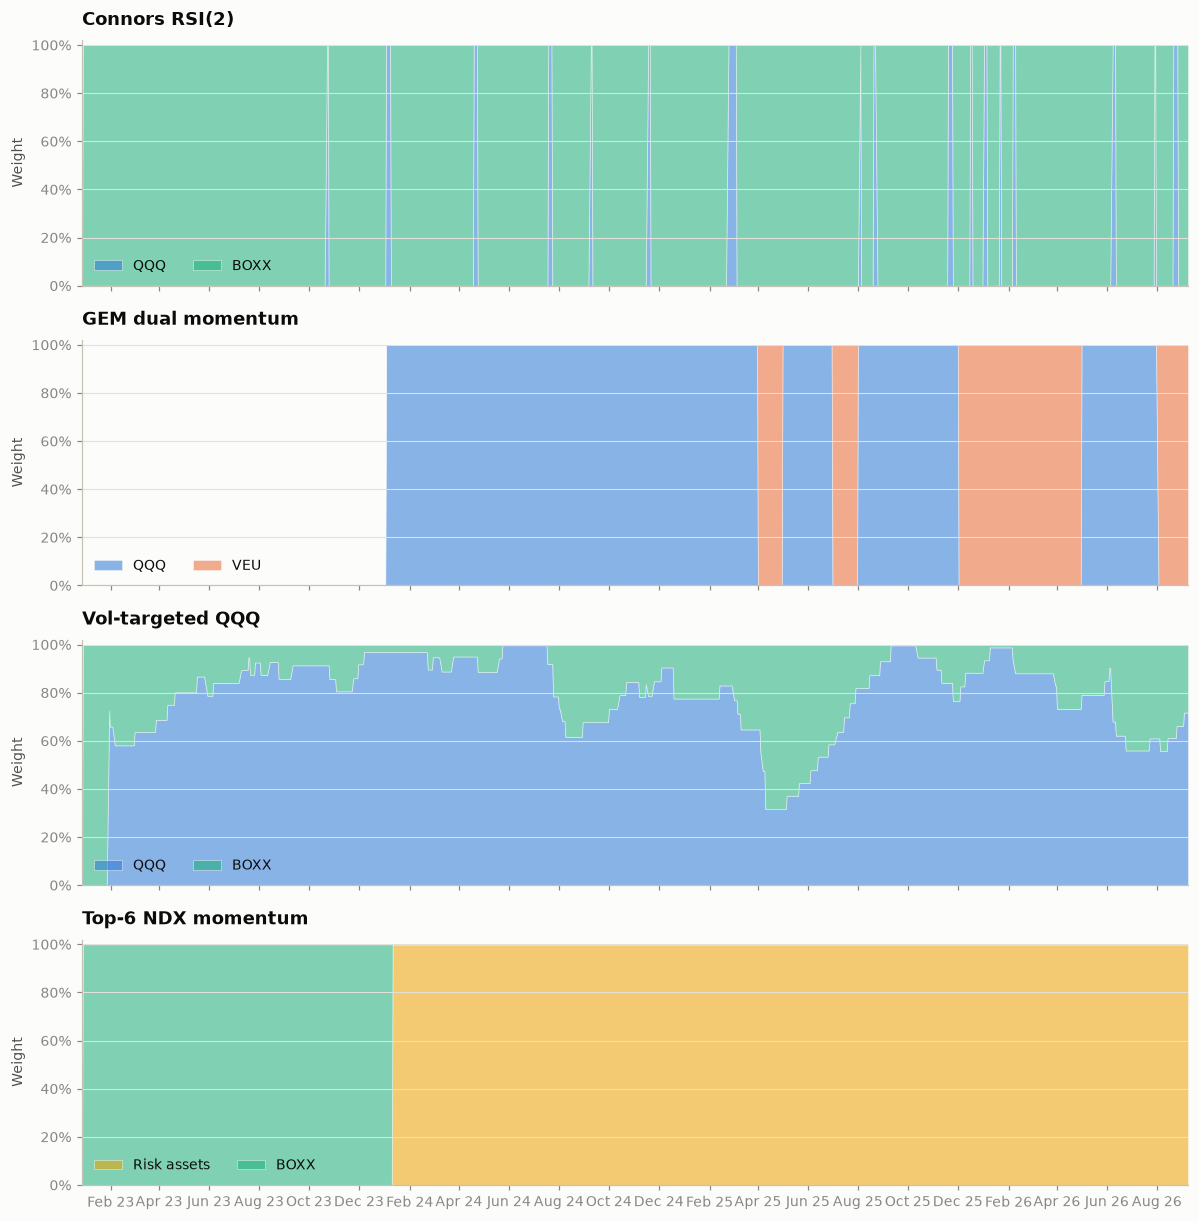

In [21]:
keys = [k for k in ["rsi2", "gem", "voltarget", "momentum"] if k in lab.results]
fig, axes = plt.subplots(len(keys), 1, figsize=(11, 2.8 * len(keys)), sharex=True)
for ax, key in zip(np.atleast_1d(axes), keys):
    P.plot_exposure(lab.results[key], title=STRATEGY_LABELS[key], ax=ax)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

## 8. Return distribution

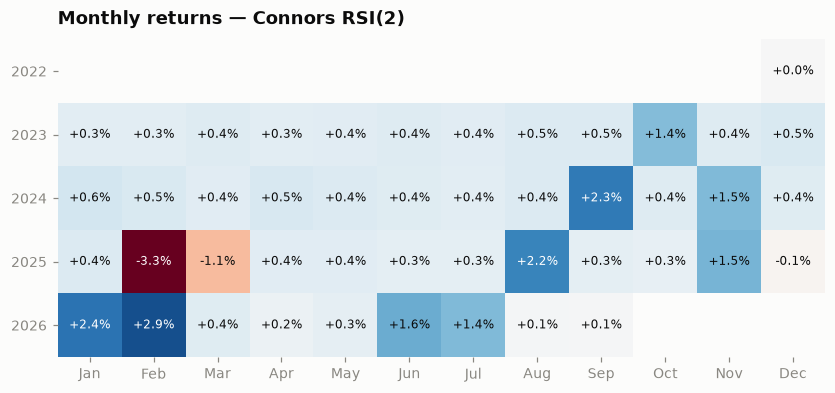

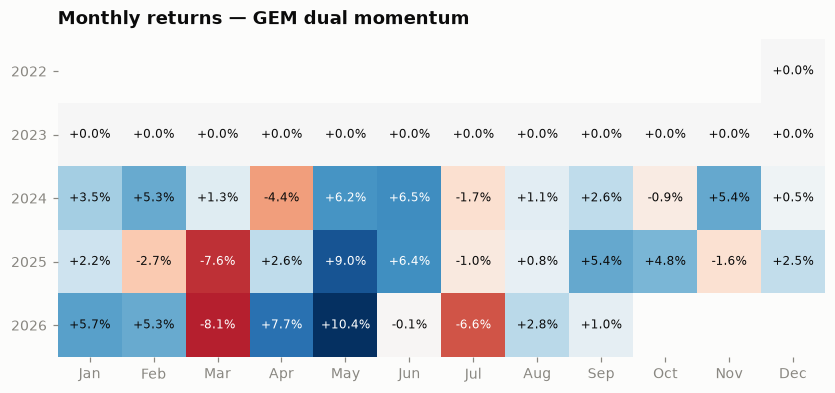

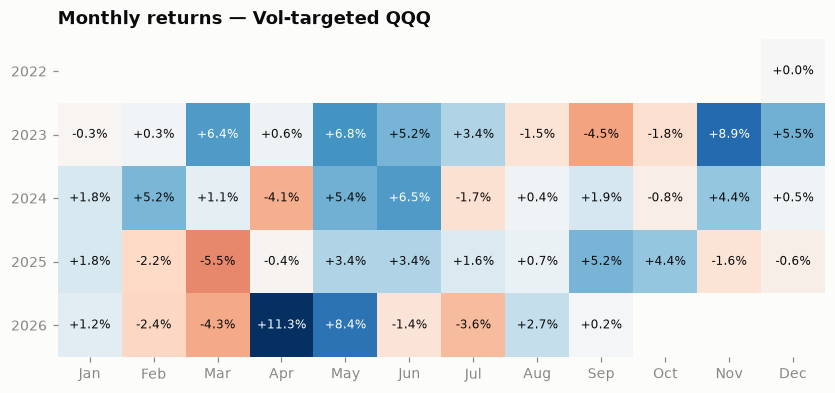

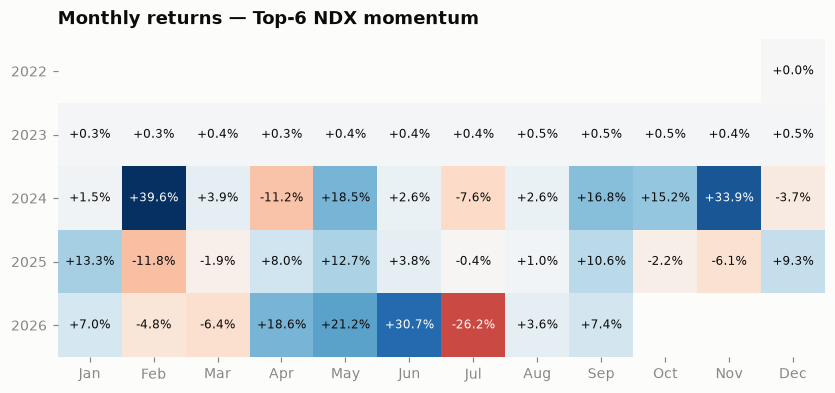

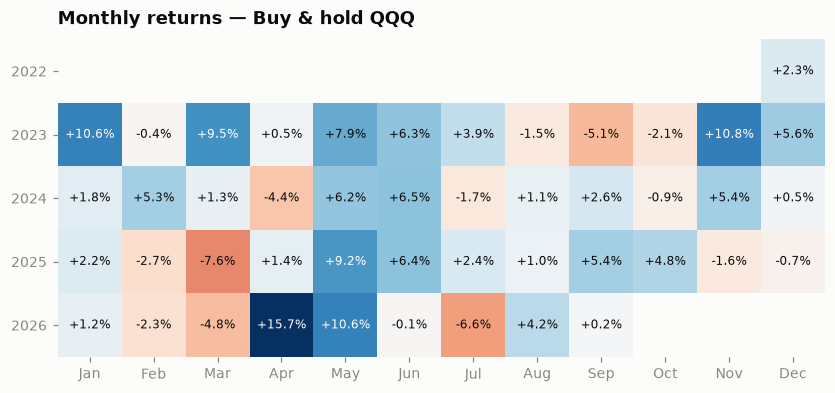

In [22]:
for key in [k for k in ["rsi2", "gem", "voltarget", "momentum", "bh_qqq"] if k in lab.results]:
    P.plot_monthly_heatmap(lab.results[key])
    plt.show()

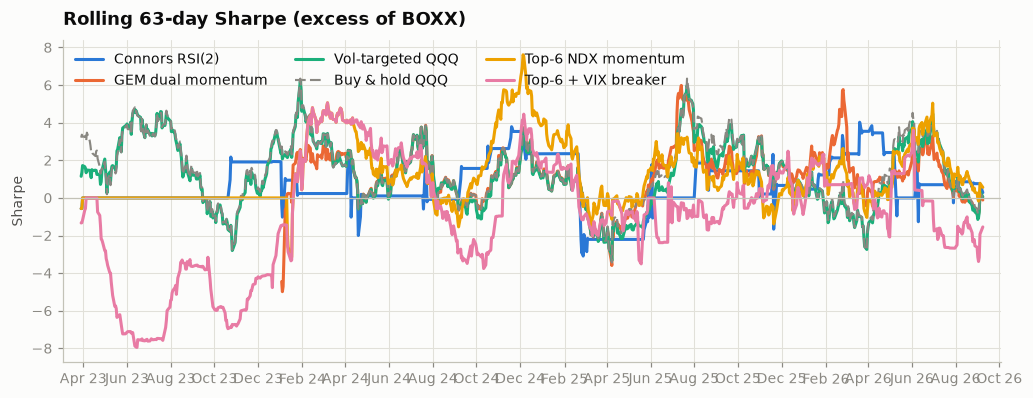

In [23]:
P.plot_rolling_sharpe(lab.results, window=63, rf=lab.rf)
plt.show()

## 9. Does the result survive the parameters?

A backtest that only works at one setting is a curve fit. These sweeps re-run the whole
thing across a grid; what you want to see is a *plateau*, not a spike. If the best
number sits alone on a cliff edge, it is noise.

In [24]:
rows = []
for thresh in [2, 3, 5, 7, 10, 15, 20]:
    for trend in [0, 100, 200]:        # 0 disables the trend filter entirely
        p = RSI2Params(entry_threshold=thresh, trend_sma=trend)
        from qbs.strategies import connors_rsi2
        sig = connors_rsi2(px, params=p)
        res = run_backtest(px, sig, start=cfg.backtest_start, end=cfg.backtest_end,
                           cost_bps=cfg.cost_bps)
        from qbs.metrics import summarise
        s = summarise(res, rf=lab.rf)
        rows.append({"RSI entry": thresh, "trend filter": f"SMA{trend}" if trend else "none",
                     "CAGR": s["CAGR"], "Sharpe": s["Sharpe (vs BOXX)"],
                     "MaxDD": s["Max drawdown"], "trades": len(sig.events) // 2})
rsi_sweep = pd.DataFrame(rows)
rsi_sweep.pivot(index="RSI entry", columns="trend filter", values="Sharpe").round(2)

trend filter,SMA100,SMA200,none
RSI entry,,,
2,0.22,0.65,0.81
3,0.40,0.70,0.83
5,0.32,0.61,0.91
7,0.43,0.83,1.16
10,0.85,1.19,1.27
15,0.88,1.09,1.29
20,0.95,1.04,1.07


In [25]:
rows = []
for tv in [0.08, 0.10, 0.12, 0.15, 0.20, 0.25]:
    for maxw in [1.0, 1.5]:
        from qbs.strategies import vol_target_overlay
        from qbs.metrics import summarise
        p = VolTargetParams(target_vol=tv, max_weight=maxw)
        sig = vol_target_overlay(px, params=p)
        res = run_backtest(px, sig, start=cfg.backtest_start, end=cfg.backtest_end,
                           cost_bps=cfg.cost_bps)
        s = summarise(res, rf=lab.rf)
        rows.append({"target vol": tv, "max weight": maxw, "CAGR": s["CAGR"],
                     "Ann. vol": s["Ann. vol"], "Sharpe": s["Sharpe (vs BOXX)"],
                     "MaxDD": s["Max drawdown"], "turnover": s["Ann. turnover"]})
vol_sweep = pd.DataFrame(rows)
vol_sweep.style.format({"target vol": "{:.0%}", "CAGR": "{:.1%}", "Ann. vol": "{:.1%}",
                        "Sharpe": "{:.2f}", "MaxDD": "{:.1%}", "turnover": "{:.1f}x"})

,target vol,max weight,CAGR,Ann. vol,Sharpe,MaxDD,turnover
0,8%,1.000000,12.8%,8.1%,0.97,-9.1%,2.0x
1,8%,1.500000,12.8%,8.1%,0.97,-9.1%,2.0x
2,10%,1.000000,15.5%,10.1%,1.02,-10.9%,2.5x
3,10%,1.500000,15.5%,10.1%,1.02,-10.9%,2.5x
4,12%,1.000000,17.3%,12.1%,1.00,-13.0%,3.2x
5,12%,1.500000,17.3%,12.1%,1.00,-13.0%,3.2x
6,15%,1.000000,20.6%,14.9%,1.02,-15.9%,3.6x
7,15%,1.500000,20.3%,15.1%,1.00,-15.9%,4.5x
8,20%,1.000000,24.2%,17.4%,1.07,-20.2%,2.2x
9,20%,1.500000,25.5%,20.1%,1.00,-21.3%,6.5x


### 9c. The hysteresis band — the parameter most likely to fool you

Turnover should fall smoothly and reliably as the band widens; that part is close to
mechanical. What matters is whether return holds up while it does.

**Look for a plateau in the Sharpe panel, not a peak.** If the best band width sits
alone on a spike with worse values either side, that is noise, and picking it is how
you overfit. A flat-ish region says the strategy is insensitive to the exact number,
which is what you want before trading it.

,n_hold,exit_rank,band,CAGR,Ann. vol,Sharpe,MaxDD,Ann. turnover,Cost drag
0,6,6,0,76.6%,41.0%,1.48,-38.4%,17.3x,1.04%
1,6,8,2,76.8%,40.3%,1.50,-35.1%,5.3x,0.32%
2,6,10,4,59.7%,39.7%,1.26,-34.8%,4.1x,0.24%
3,6,12,6,72.3%,40.1%,1.45,-35.8%,2.9x,0.17%
4,6,15,9,62.6%,38.9%,1.33,-35.8%,2.7x,0.16%
5,6,20,14,63.9%,38.5%,1.36,-35.1%,2.3x,0.14%
6,6,25,19,62.4%,38.0%,1.35,-33.6%,2.3x,0.14%
7,6,30,24,58.0%,37.0%,1.30,-35.1%,2.2x,0.13%


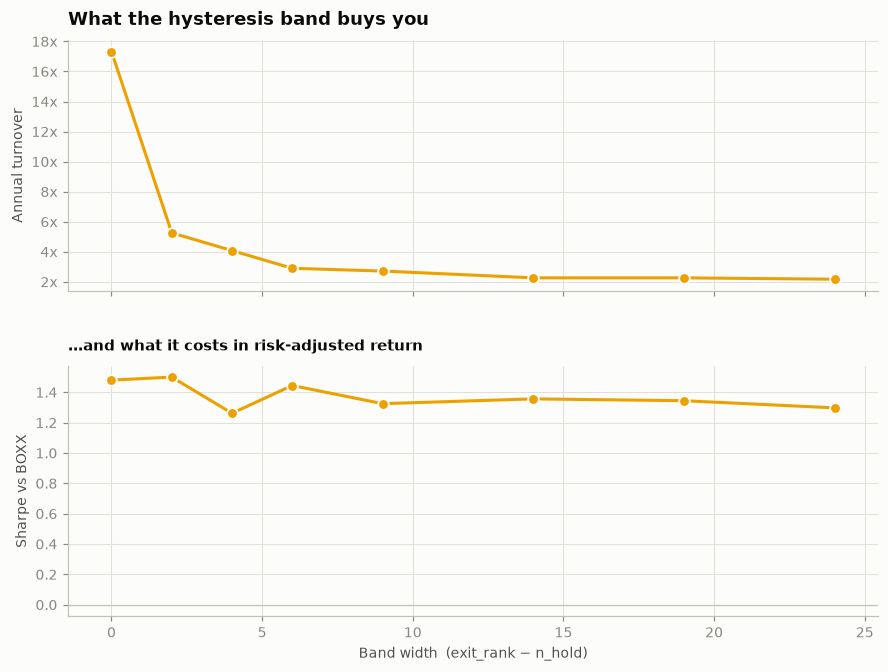

In [26]:
from qbs.pipeline import sweep_band
band_sweep = sweep_band(lab, n_holds=[cfg.momentum.n_hold],
                        exit_ranks=[6, 8, 10, 12, 15, 20, 25, 30])
display(band_sweep.style.format({
    "CAGR": "{:.1%}", "Ann. vol": "{:.1%}", "Sharpe": "{:.2f}",
    "MaxDD": "{:.1%}", "Ann. turnover": "{:.1f}x", "Cost drag": "{:.2%}"}))
fig = P.plot_band_sensitivity(band_sweep, n_hold=cfg.momentum.n_hold)
plt.show()

In [ ]:
# How many names to hold? Same warning applies — look for a region, not a winner.
wide = sweep_band(lab, n_holds=[3, 4, 6, 8, 10, 15], exit_ranks=[10, 15, 20, 30])
wide.pivot(index="n_hold", columns="exit_rank", values="Sharpe").round(2)

### 9d. How much does the slippage assumption matter?

The strategy decides on a ~15:30 price and fills in the 16:00 closing auction. That gap
is modelled as `slippage_bps` on turnover. If the result only survives at optimistic
slippage, it is an execution bet rather than a strategy.

In [ ]:
from qbs.metrics import summarise
rows = []
for slip in [0, 2, 5, 10, 20, 40]:
    for key in [k for k in ["momentum", "rsi2", "voltarget"] if k in lab.signals]:
        book = lab.combined if key == "momentum" else px
        res = run_backtest(book, lab.signals[key], start=cfg.backtest_start,
                           end=cfg.backtest_end, cost_bps=cfg.cost_bps,
                           slippage_bps=slip)
        rows.append({"slippage (bps)": slip, "strategy": STRATEGY_LABELS[key],
                     "CAGR": summarise(res, lab.rf)["CAGR"]})
slip_tbl = pd.DataFrame(rows).pivot(index="slippage (bps)", columns="strategy", values="CAGR")
slip_tbl.style.format("{:.1%}")

strategy,Connors RSI(2),Top-6 NDX momentum,Vol-targeted QQQ
slippage (bps),,,
0,8.1%,60.0%,20.6%
2,7.7%,59.9%,20.5%
5,7.1%,59.7%,20.4%
10,6.1%,59.3%,20.2%
20,4.1%,58.7%,19.7%
40,0.2%,57.4%,18.8%


### 9e. Where should the VIX trigger sit?

This is the sweep that decides whether the breaker is a crash filter or an exit from
the market. Read **Time invested** before anything else: as the trigger rises through
the VIX distribution the strategy converges back to unprotected momentum, and as it
falls the strategy converges to cash. Somewhere in between is the only region worth
arguing about.

A drawdown improvement bought by sitting out most of the sample is not risk
management — it is a smaller position. Compare the CAGR column against the
unprotected line.

,exit,entry,Time invested,Trips,CAGR,Ann. vol,Sharpe,MaxDD,Ann. turnover
0,16,15.000000,33%,22,10.0%,18.4%,0.36,-35.8%,20.5x
1,17,16.000000,47%,29,12.3%,23.1%,0.42,-26.2%,24.8x
2,18,17.000000,59%,27,13.1%,27.4%,0.42,-35.3%,23.7x
3,20,19.000000,77%,27,13.0%,32.3%,0.40,-40.2%,23.9x
4,22,21.000000,88%,15,32.2%,35.0%,0.84,-34.8%,13.9x
5,25,24.000000,94%,11,35.7%,37.1%,0.88,-37.9%,12.0x
6,30,29.000000,98%,3,58.5%,38.5%,1.27,-34.8%,6.1x
7,35,34.000000,99%,3,54.1%,39.2%,1.18,-36.9%,5.6x


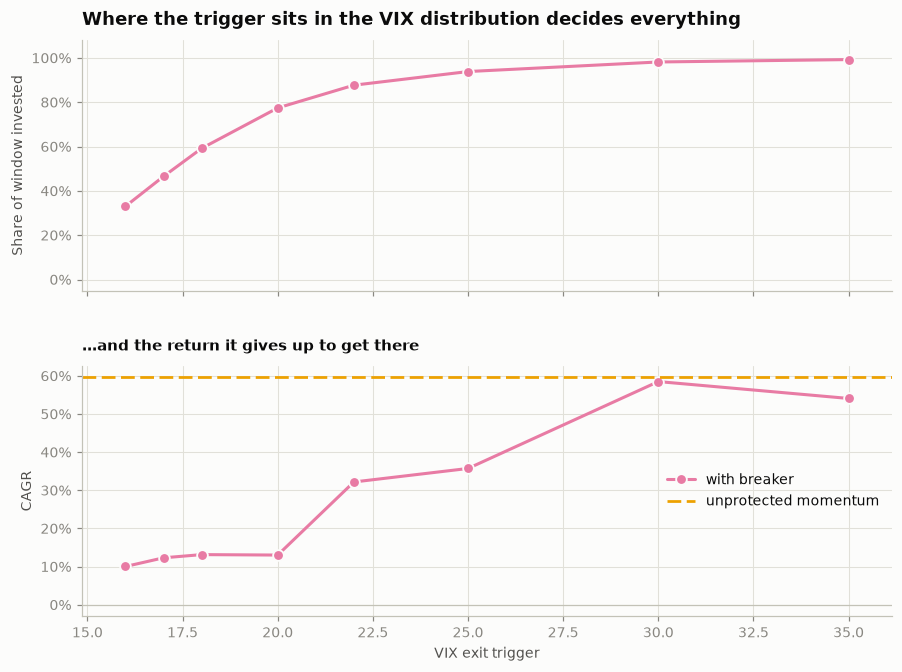

In [ ]:
if "momentum_vix" in lab.signals:
    vix_sweep = sweep_vix(lab, exit_levels=[16, 17, 18, 20, 22, 25, 30, 35], band=1.0)
    base_cagr = lab.summary.loc[STRATEGY_LABELS["momentum"], "CAGR"]
    display(vix_sweep.style.format({
        "Time invested": "{:.0%}", "CAGR": "{:.1%}", "Ann. vol": "{:.1%}",
        "Sharpe": "{:.2f}", "MaxDD": "{:.1%}", "Ann. turnover": "{:.1f}x"}))
    fig = P.plot_vix_sweep(vix_sweep, baseline_cagr=base_cagr)
    plt.show()

### 9f. How much does the vol target matter?

Unlike the VIX trigger, this dial should be **boring**: a lower target is simply less
of the same book, so CAGR and drawdown ought to fall together and Calmar should stay
roughly flat. That is what robustness looks like here — a *kink* would mean the
overlay is doing something other than rescaling, and would be a bug worth chasing.

Compare each row against the unscaled book's own CAGR and drawdown (the dashed
reference lines). The column to choose on is **Max drawdown**, because that is the
one you have to sit through.

In [ ]:
tv_sweep = sweep_target_vol(lab, targets=[0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50])
_base = lab.summary.loc[STRATEGY_LABELS["momentum"]]

display(tv_sweep.style.format({
    "Target vol": "{:.0%}", "CAGR": "{:.1%}", "Ann. vol": "{:.1%}", "Sharpe": "{:.2f}",
    "Max drawdown": "{:.1%}", "Calmar": "{:.2f}", "Ann. turnover": "{:.1f}x",
    "Avg exposure": "{:.0%}"}))

fig = P.plot_target_vol_sweep(tv_sweep, baseline=_base.to_dict())
plt.show()

In [ ]:
# Second robustness axis: the EWMA halflife. If the result only survives at
# halflife=20 it is a fitted parameter, not a risk control.
from qbs.config import BookVolTargetParams

_rows = []
for _hl in (10, 15, 20, 30, 40, 60):
    _s = book_vol_target(lab.signals["momentum"], lab.combined,
                         BookVolTargetParams(**{**cfg.book_vol.__dict__,
                                                "target_vol": TARGET_VOL, "halflife": _hl}),
                         lag=cfg.execution_lag)
    _r = run_backtest(lab.combined, _s, start=cfg.backtest_start, end=cfg.backtest_end,
                      lag=cfg.execution_lag, cost_bps=cfg.cost_bps,
                      slippage_bps=cfg.slippage_bps)
    _m = summarise(_r, rf=lab.rf)
    _rows.append({"halflife": _hl, "CAGR": _m["CAGR"], "Max drawdown": _m["Max drawdown"],
                  "Sharpe": _m["Sharpe (vs BOXX)"], "Calmar": _m["Calmar"],
                  "Ann. turnover": _m["Ann. turnover"]})

display(pd.DataFrame(_rows).style.format({
    "CAGR": "{:.1%}", "Max drawdown": "{:.1%}", "Sharpe": "{:.2f}",
    "Calmar": "{:.2f}", "Ann. turnover": "{:.1f}x"}).hide(axis="index"))

**What this overlay does not do.** It rescales risk; it does not add return — Sharpe
is roughly unchanged and what improves is Calmar, because de-levering cuts drawdown
faster than it cuts return. It cannot help with an overnight gap in a single name: it
responds to sustained volatility, not to jumps, and a sixth of the book in one name
still means a ~5% portfolio hit from one bad earnings print. Resting stops at the
broker are the mitigation, and they live outside this backtest.

And the sample is still twenty months — one regime, roughly 400 trading days. Vol
clustering is about the most durable effect in finance, so this should generalise
better than most backtest findings, but "should" is not "does".

## 10. Stacking the overlay on the other two

Vol targeting is an *overlay*, not only a standalone strategy. Applied on top of
RSI(2) or GEM it multiplies whatever risk weight that strategy wanted by the vol
scalar, so it can only ever cut exposure (or gear it, if you raise `max_weight`
above 1). This is usually the more interesting way to use it.

In [ ]:
from qbs.strategies import vol_target_overlay
stacked = dict(lab.results)
for base_key in ["rsi2", "gem"]:
    sig = vol_target_overlay(px, base_weights=lab.signals[base_key].weights,
                             params=cfg.vol, name=f"{base_key}_vt")
    stacked[f"{base_key}_vt"] = run_backtest(
        px, sig, start=cfg.backtest_start, end=cfg.backtest_end,
        cost_bps=cfg.cost_bps, slippage_bps=cfg.slippage_bps)

labels = dict(STRATEGY_LABELS)
labels.update({"rsi2_vt": "RSI(2) + vol overlay", "gem_vt": "GEM + vol overlay"})
format_summary(summary_table(stacked, rf=lab.rf, labels=labels))

,Total return,CAGR,Ann. vol,Sharpe (vs BOXX),Sortino,Max drawdown,Calmar,Best day,Worst day,Hit rate,Avg risk exposure,Days in risk,Ann. turnover,Cost drag (ann.),of which slippage
Connors RSI(2),28.5%,7.1%,5.5%,0.44,0.68,-5.9%,1.19,3.4%,-2.8%,73.1%,5.6%,5.6%,18.8x,1.1%,0.9%
GEM dual momentum,82.9%,17.9%,16.7%,0.79,1.14,-22.3%,0.80,7.2%,-6.1%,41.5%,72.6%,72.6%,4.1x,0.2%,0.2%
Vol-targeted QQQ,97.7%,20.4%,14.9%,1.01,1.44,-15.9%,1.28,5.7%,-4.3%,57.7%,77.9%,97.7%,3.6x,0.2%,0.2%
Buy & hold QQQ,181.7%,32.6%,20.2%,1.27,1.90,-22.8%,1.43,12.0%,-6.2%,56.8%,99.9%,99.9%,0.3x,0.0%,0.0%
Buy & hold BOXX,18.3%,4.7%,0.4%,-0.04,-0.52,-0.1%,40.46,0.1%,-0.1%,75.6%,0.0%,0.0%,0.3x,0.0%,0.0%
Top-6 NDX momentum,458.1%,59.7%,39.7%,1.26,1.92,-34.8%,1.71,14.6%,-10.2%,60.4%,71.9%,71.9%,4.1x,0.2%,0.2%
Top-6 + VIX breaker,53.2%,12.3%,23.1%,0.42,0.61,-26.2%,0.47,8.6%,-9.4%,58.9%,33.8%,33.8%,24.8x,1.5%,1.2%
RSI(2) + vol overlay,26.9%,6.7%,4.4%,0.45,0.69,-4.8%,1.41,2.3%,-2.3%,73.1%,4.7%,5.6%,15.8x,0.9%,0.8%
GEM + vol overlay,49.6%,11.6%,11.2%,0.62,0.86,-11.5%,1.00,2.8%,-4.3%,65.8%,43.3%,54.0%,4.8x,0.3%,0.2%


## 11. Verification

Three things worth checking before believing any of the above.

In [ ]:
# (1) No look-ahead. Every strategy here decides at a close and trades the next
#     day. Re-running with lag=0 lets each one earn the return of the very day
#     its signal fired -- which is not tradeable, and is the single most common
#     way a backtest lies.
#
#     Read the sign, not just the size. A large POSITIVE gap (lag=0 much better)
#     is the red flag: the edge lived in a bar you could not have traded.
#     A NEGATIVE gap is expected for RSI(2), because it buys on the day of a
#     sharp fall -- cheating would hand it that fall. GEM should barely move
#     either way, since its decisions sit at month ends.
from qbs.metrics import summarise
print(f"{'strategy':<22} {'lag=1 (tradeable)':>18} {'lag=0 (cheating)':>18} {'gap':>8}")
for key in [k for k in ["rsi2", "gem", "voltarget", "momentum"] if k in lab.signals]:
    book = lab.combined if key == "momentum" else px
    honest = run_backtest(book, lab.signals[key], start=cfg.backtest_start,
                          end=cfg.backtest_end, lag=1, cost_bps=cfg.cost_bps)
    cheat = run_backtest(book, lab.signals[key], start=cfg.backtest_start,
                         end=cfg.backtest_end, lag=0, cost_bps=cfg.cost_bps)
    h, c = summarise(honest, lab.rf)["CAGR"], summarise(cheat, lab.rf)["CAGR"]
    print(f"{STRATEGY_LABELS[key]:<22} {h:>17.2%} {c:>18.2%} {c - h:>8.2%}")

strategy                lag=1 (tradeable)   lag=0 (cheating)      gap
Connors RSI(2)                     8.08%             -5.71%  -13.79%
GEM dual momentum                 18.10%             16.62%   -1.48%
Vol-targeted QQQ                  20.60%             21.36%    0.77%
Top-6 NDX momentum                59.99%             60.53%    0.54%


In [ ]:
# (1b) The momentum score itself must never see the future. Perturb prices after a
#      date and confirm no score on or before that date moves.
if "momentum" in lab.signals:
    from qbs.strategies import cross_sectional_momentum
    uni = lab.combined.drop(columns=["BOXX"])
    cut = uni.index[len(uni) // 2]
    tampered = uni.copy()
    tampered.loc[tampered.index > cut] *= 5.0
    a = lab.signals["momentum"].momentum.loc[:cut]
    b = cross_sectional_momentum(tampered, px["BOXX"], cfg.momentum).momentum.loc[:cut]
    drift = (a - b).abs().max().max()
    print(f"max change in any pre-{cut:%Y-%m-%d} momentum score after "
          f"multiplying all later prices by 5: {drift:.2e}")
    assert drift < 1e-12, "LOOK-AHEAD: the score responded to future prices"
    print("no look-ahead in the ranking signal")

max change in any pre-2024-10-31 momentum score after multiplying all later prices by 5: 0.00e+00
no look-ahead in the ranking signal


In [ ]:
# (2) Weights are sane: no shorts, no accidental leverage, no NaN leaking into returns.
for key, res in lab.results.items():
    w = res.weights
    assert (w >= -1e-9).all().all(), f"{key}: short position"
    assert (w.sum(axis=1) <= cfg.vol.max_weight + 1e-9).all(), f"{key}: leverage"
    assert res.returns.notna().all(), f"{key}: NaN in returns"
print("weight and return invariants hold for all strategies")

weight and return invariants hold for all strategies


In [ ]:
# (3) The unit tests, run from here.
import subprocess, sys
r = subprocess.run([sys.executable, "../tests/test_qbs.py"], capture_output=True, text=True)
print(r.stdout[-2000:] or r.stderr[-2000:])

SS  test_drawdown_never_positive
  PASS  test_execution_lag_actually_lags
  PASS  test_full_pipeline_runs_and_aligns
  PASS  test_gem_goes_defensive_when_equities_lag_cash
  PASS  test_gem_holds_exactly_one_asset
  PASS  test_gem_picks_the_stronger_sleeve
  PASS  test_membership_mask_forward_fills
  PASS  test_metrics_are_finite_and_sane
  PASS  test_momentum_absolute_filter_goes_to_cash
  PASS  test_momentum_band_of_zero_is_the_naive_strategy
  PASS  test_momentum_band_reduces_turnover_monotonically
  PASS  test_momentum_has_no_lookahead_in_the_score
  PASS  test_momentum_holds_at_most_n_and_is_slot_weighted
  PASS  test_momentum_min_history_blocks_young_names
  PASS  test_momentum_rejects_impossible_band
  PASS  test_momentum_respects_membership_mask
  PASS  test_overlay_can_only_shrink_the_base_exposure
  PASS  test_rsi2_never_enters_below_trend
  PASS  test_rsi2_respects_time_stop
  PASS  test_rsi_bounds_and_warmup
  PASS  test_rsi_known_seed_value
  PASS  test_rsi_monotone_down_is

## 12. Caveats — read these

* **Survivorship bias in the Nasdaq-100 universe.** Unless you supplied point-in-time
  membership, the ranking universe is *today's* index applied to the whole history —
  and today's Nasdaq-100 is, close to by definition, a list of stocks that went up.
  A momentum strategy restricted to that list has been quietly handed the answer. The
  index reconstitutes each December plus ad-hoc M&A and delisting changes, so over
  twenty months this is not fatal, but it is real and it flatters the result. The fix
  is `universe.load_pit_universe()` plus a membership file; see `qbs/universe.py`.
* **A VIX trigger at 17 is not a crash filter.** VIX's long-run median sits near
  17–18, so that trigger fires on ordinary market conditions, not on stress. Section 9e
  shows what it costs. If you want a crash filter, the trigger has to sit in the tail —
  and note that VIX *level* is a weak timing signal in the literature anyway, because
  high implied vol tends to precede high future returns (the volatility risk premium).
  The VIX term structure (VIX vs VIX3M) is the more common professional choice.
* **Six names is a concentrated bet.** The backtest reports portfolio volatility, but
  it cannot show you the risk that actually ends these strategies: one holding gapping
  30% on an earnings miss overnight. With a sixth of the book in each name, that is a
  5% portfolio hit from a single print, and a daily-rebalanced system cannot dodge it.
* **Short-term capital gains.** At the turnover levels in section 9c, a taxable account
  converts most of the return into short-term gains taxed as income. Compare the
  after-tax figure with simply holding QQQ before concluding anything.
* **The sample is twenty months long.** That is roughly 400 trading days and, for GEM,
  about 20 monthly decisions. Nothing in this notebook is statistically significant.
  A Sharpe ratio estimated over twenty months has a standard error near 0.8.
* **One regime.** The window contains a specific sequence of events. Any strategy that
  happened to be defensive during the April 2025 drawdown looks brilliant; that is not
  evidence it will be defensive during the next one.
* **RSI(2) barely trades here.** With an entry at 5 and a 200-day filter, the strategy
  spends most of the window in BOXX. Most of its return *is* the BOXX yield. Check the
  "Avg risk exposure" column before reading anything into its Sharpe.
* **GEM is being asked to do something it wasn't designed for.** Antonacci's version
  uses broad indices and a decade-plus evaluation horizon. Twenty months with QQQ in
  the equity slot is a different, more concentrated bet.
* **Vol targeting rescales risk; it does not add return.** If QQQ's Sharpe is negative,
  running it at 15% vol instead of 25% loses money more slowly. That is the whole claim.
* **BOXX has its own risks** the backtest treats as zero: it is an ETF holding box
  spreads, so it carries counterparty and liquidity risk, and its tax treatment is
  the reason it exists. It is *not* a Treasury.
* **No taxes, no slippage beyond the flat cost, no dividend timing.** Prices are
  yfinance's split- and dividend-adjusted closes. RSI(2) at these turnover levels in a
  taxable account would be materially worse after tax.
* This is a backtesting exercise, not investment advice — I'm not a financial adviser.
  Past results, especially over twenty months, tell you very little about the future.